In [7]:
import heapq
import random
from collections import defaultdict
from typing import List, Dict, TypeAlias, Tuple, NamedTuple

import matplotlib.pyplot as plt
import networkx as nx

UNREACHABLE = float('inf')


class TEdge(NamedTuple):
    u: int
    v: int
    w: int


TGraph: TypeAlias = List[List[Tuple[int, int]]]
TShortestPath: TypeAlias = Tuple[List[float], List[int]]
TAllShortestPaths: TypeAlias = Dict[tuple[int, int], tuple[int, List[int]]]


class TEdgeDualWeighted(NamedTuple):
    u: int
    v: int
    bandwidth: int
    delay: int


TGraphDualWeighted: TypeAlias = List[List[Tuple[int, int, int]]]
TShortestPathDualWeighted: TypeAlias = Tuple[List[float], List[float], List[int]]
TAllShortestPathsDualWeighted: TypeAlias = Dict[tuple[int, int], tuple[float, float, List[int]]]

In [8]:
def generate_multigraph(
    vertices_num: int,
    degrees_choices: List[int],
    multiple_edges_choices: List[int],
    weights_choices: List[int],
) -> List[TEdge]:
    def get_target_vertex(u: int) -> int:
        while True:
            v = random.randint(0, vertices_num - 1)
            if u != v:
                return v

    edges = []
    for u in range(vertices_num):
        for _ in range(random.choice(degrees_choices)):
            v = get_target_vertex(u)
            for _ in range(random.choice(multiple_edges_choices)):
                w = random.choice(weights_choices)
                edges.append(TEdge(u, v, w))

    return edges


def build_adjacency_list(edges: List[TEdge], vertices_num: int) -> TGraph:
    adjacency_list = [[] for _ in range(vertices_num)]

    for edge in edges:
        adjacency_list[edge.u].append((edge.v, edge.w))
        adjacency_list[edge.v].append((edge.u, edge.w))

    return adjacency_list

In [10]:
def weighted_dijkstra_with_paths(graph: TGraph, start: int) -> TShortestPath:
    """
    Implements Dijkstra's algorithm to find the shortest paths from the start vertex to all other vertices.

    :param graph: Adjacency list representation of the graph.
    :param start: Starting vertex for the algorithm.
    :return: Tuple containing the list of shortest distances and the list of previous vertices for path reconstruction.
    """

    distances = [UNREACHABLE] * len(graph)
    previous = [-1] * len(graph)
    distances[start] = 0
    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_vertex = heapq.heappop(priority_queue)

        if current_distance > distances[current_vertex]:
            continue

        for neighbor, weight in graph[current_vertex]:
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_vertex
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances, previous


def reconstruct_path(previous: List[int], target: int) -> List[int]:
    path = []
    while target != -1:
        path.append(target)
        target = previous[target]

    return path[::-1]

In [11]:
def calculate_all_shortest_paths(graph: TGraph) -> TAllShortestPaths:
    all_shortest_paths = {}
    for start in range(len(graph)):
        distances, previous = weighted_dijkstra_with_paths(graph, start)
        for end in range(len(previous)):
            if start == end or distances[end] == UNREACHABLE:
                continue

            all_shortest_paths[(start, end)] = (distances[end], reconstruct_path(previous, end))

    return all_shortest_paths


def select_shortest_path_edges(
    all_shortest_paths: TAllShortestPaths | TAllShortestPathsDualWeighted,
    option: str = 'smallest',
) -> List[TEdge]:
    if option == 'smallest':
        key = min(all_shortest_paths, key=lambda k: all_shortest_paths[k][0])
    elif option == 'largest':
        key = max(all_shortest_paths, key=lambda k: all_shortest_paths[k][0])
    else:
        raise ValueError("Option must be 'smallest' or 'largest'.")

    *_, path = all_shortest_paths[key]
    return [TEdge(path[i], path[i + 1], 1) for i in range(len(path) - 1)]

In [12]:
def visualize_graph(
    vertices_num: int,
    edges: List[TEdge | TEdgeDualWeighted],
    title: str,
    smallest_shortest_path: List[TEdge],
    largest_shortest_path: List[TEdge],
):
    G = nx.MultiGraph()
    G.add_nodes_from(range(vertices_num))
    for k, e in enumerate(edges):
        G.add_edge(e.u, e.v, key=k)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_color="lightgray", node_size=50)
    nx.draw_networkx_labels(G, pos, font_size=4)

    groups = defaultdict(list)
    for u, v, key, data in G.edges(keys=True, data=True):
        groups[(u, v)].append(key)

    for (u, v), edges in groups.items():
        for i in range(len(edges)):
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                width=0.4,
                edge_color='lightblue',
                connectionstyle=f"arc3,rad={0.05 * (i + 1)}"
            )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=smallest_shortest_path,
        edge_color='green',
    )
    nx.draw_networkx_edges(
        G, pos,
        edgelist=largest_shortest_path,
        edge_color='red',
    )

    plt.title(title, fontsize=10)
    plt.axis("off")
    plt.margins(0)
    plt.tight_layout(pad=0.01)
    plt.show()

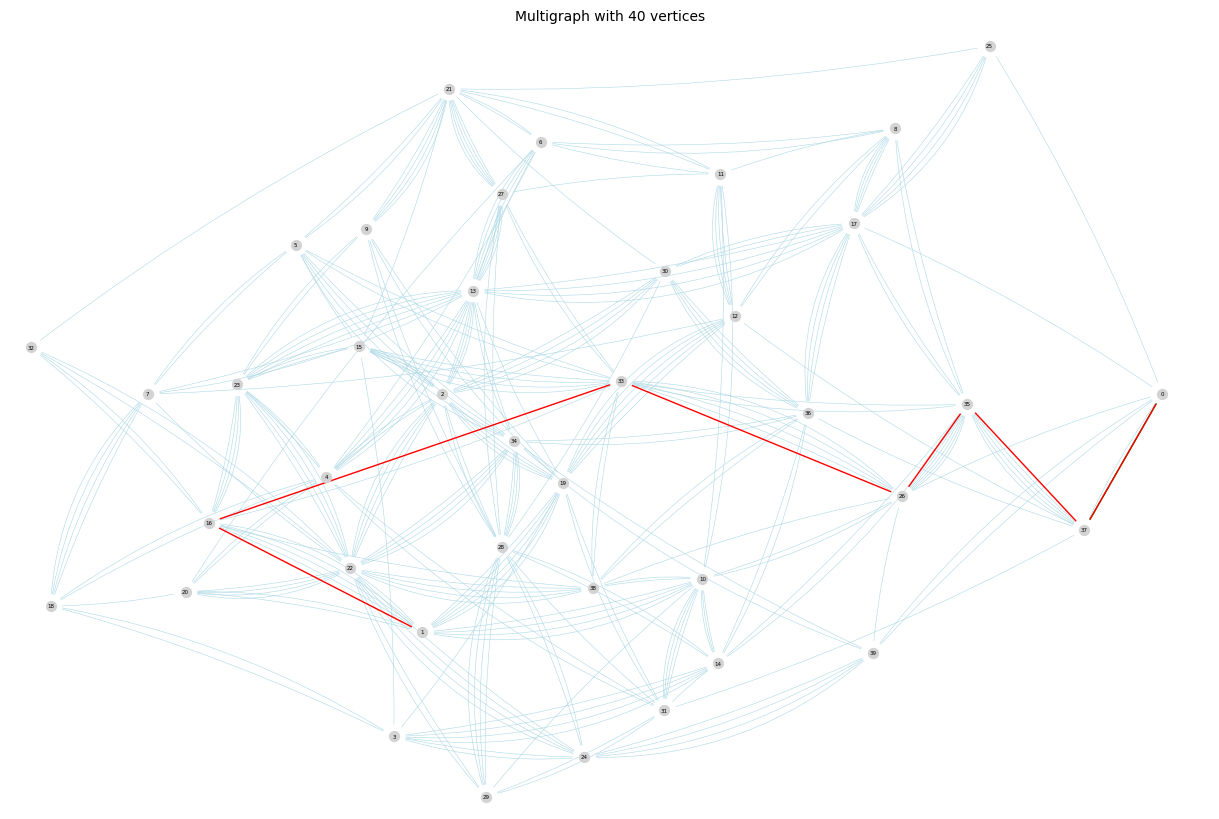

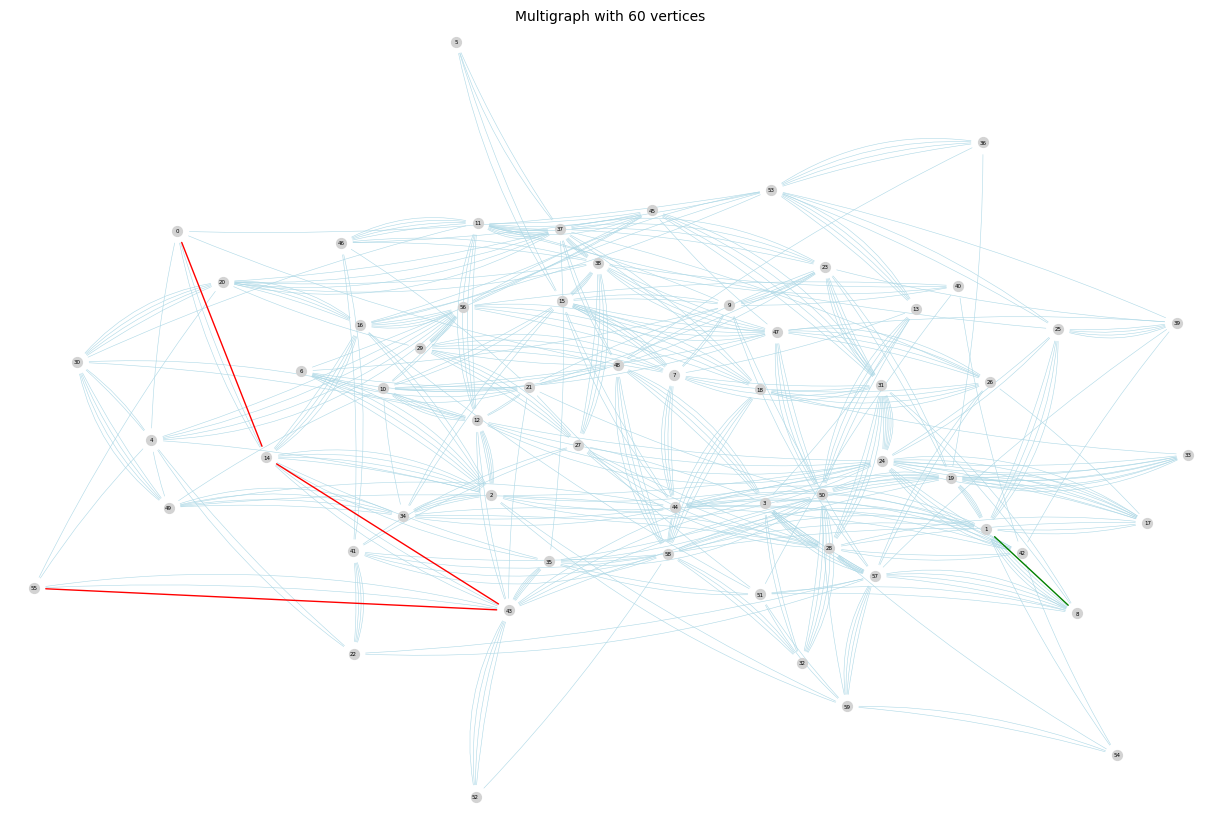

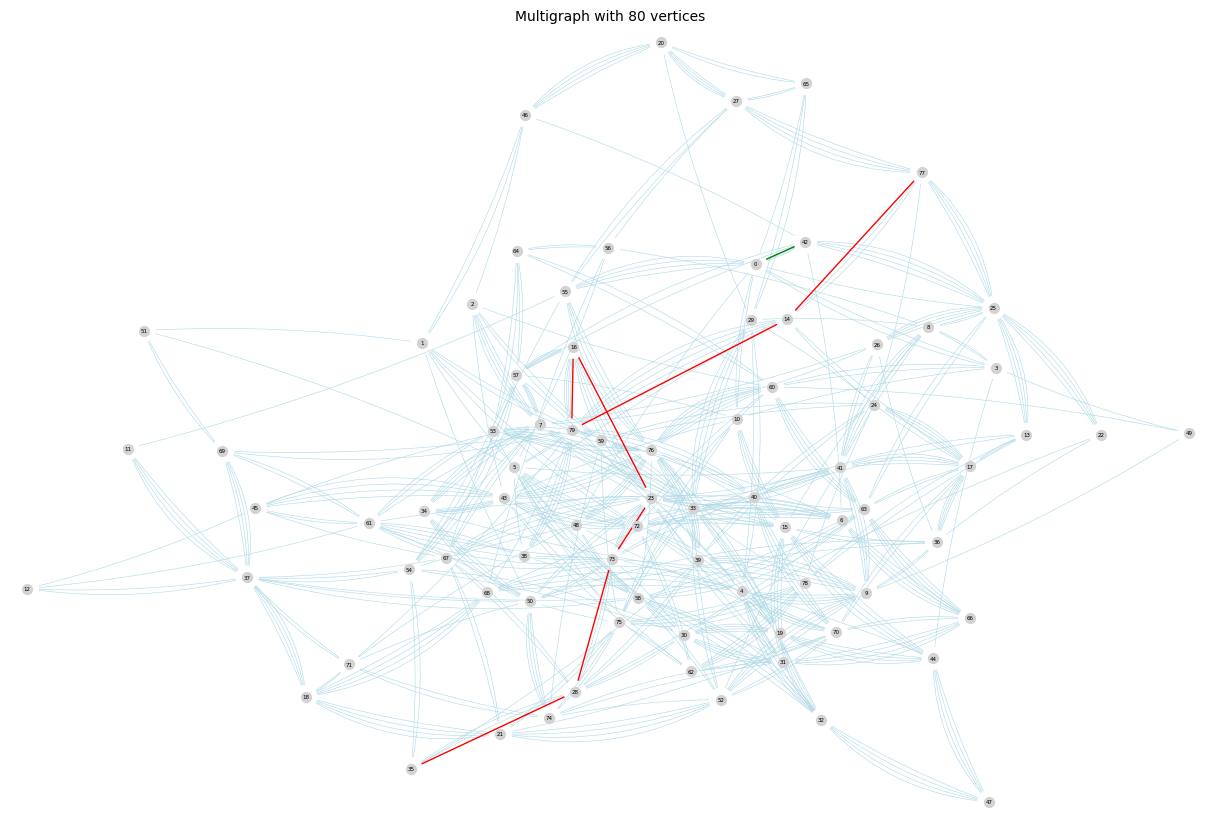

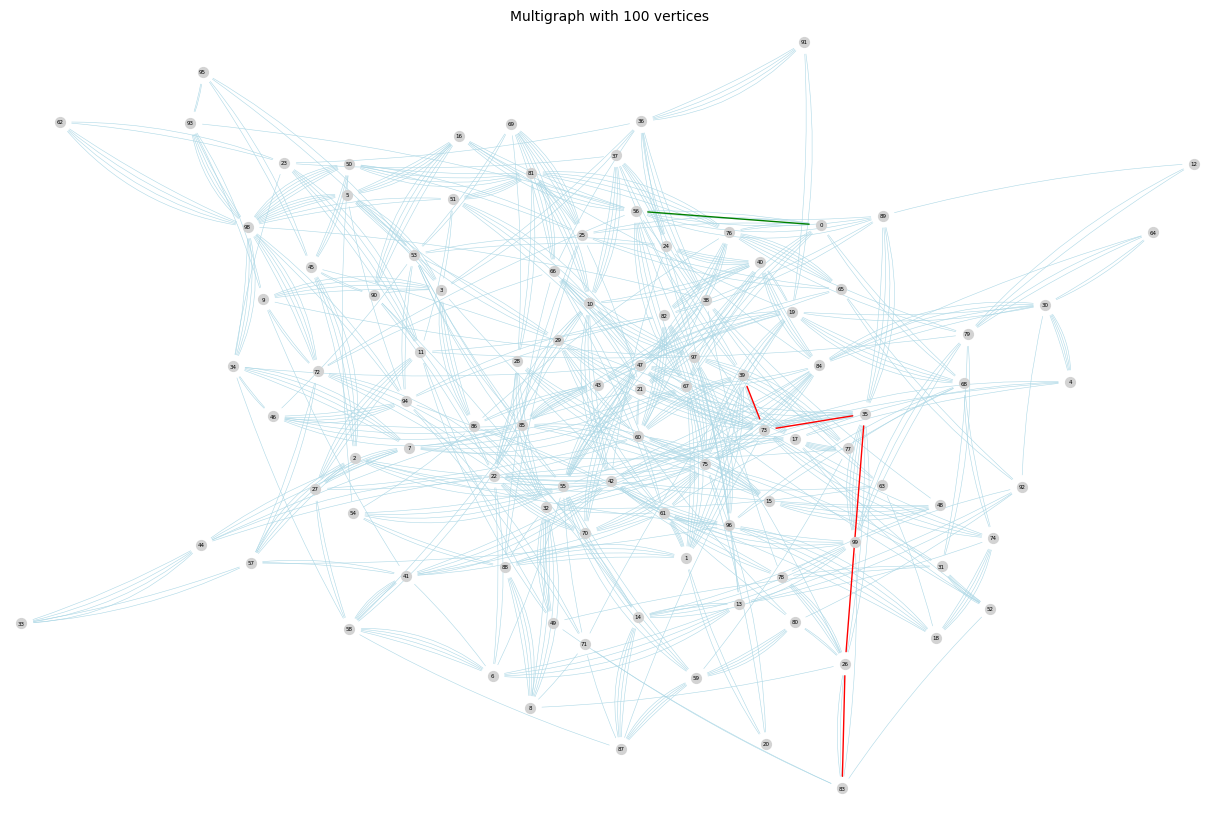

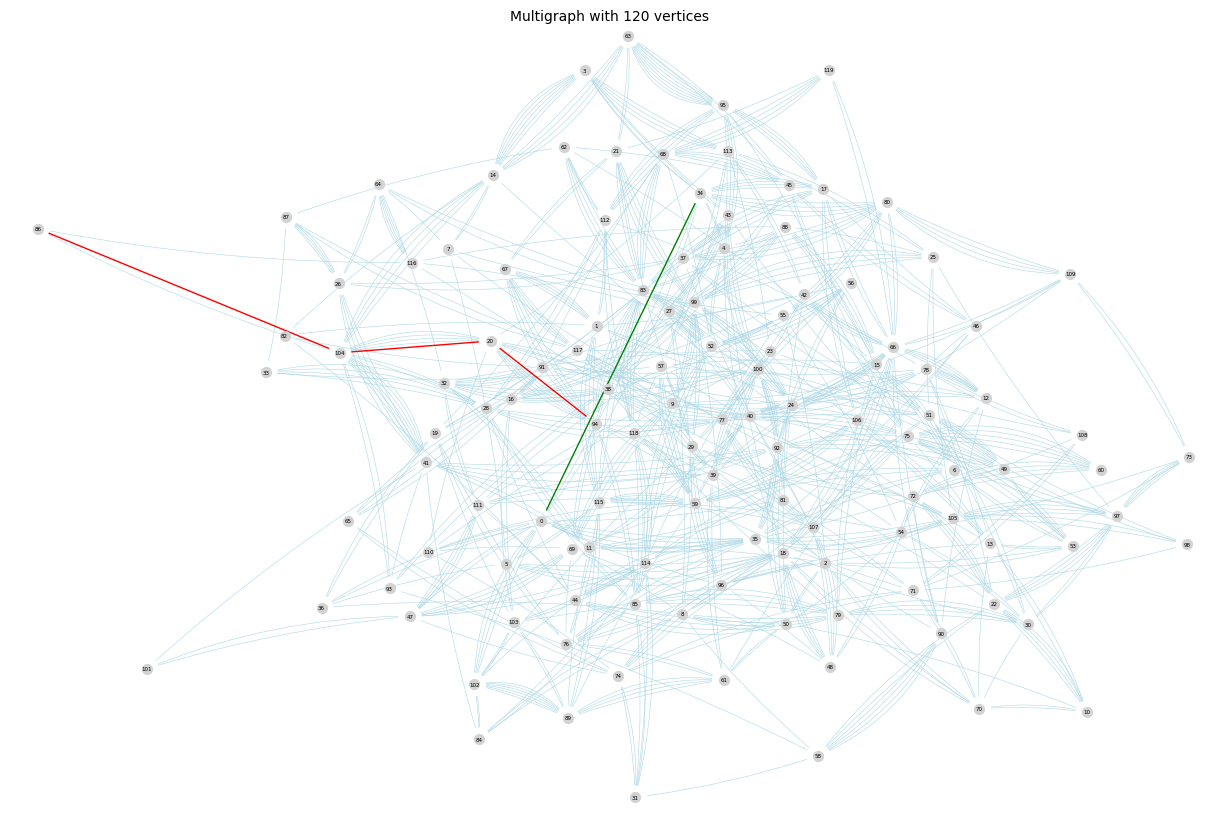

In [14]:
VERTEXES_NUM_CHOICES = (40, 60, 80, 100, 120)
DEGREES_CHOICES = (2, 3, 4)
MULTIPLE_EDGES_CHOICES = (1, 2, 4)
WEIGHTS_CHOICES = (1, 50, 100)

for vertices_num in VERTEXES_NUM_CHOICES:
    edges = generate_multigraph(
        vertices_num,
        DEGREES_CHOICES,
        MULTIPLE_EDGES_CHOICES,
        WEIGHTS_CHOICES,
    )

    shortest_paths = calculate_all_shortest_paths(build_adjacency_list(edges, vertices_num))

    visualize_graph(
        vertices_num,
        edges,
        f"Multigraph with {vertices_num} vertices",
        select_shortest_path_edges(shortest_paths, 'smallest'),
        select_shortest_path_edges(shortest_paths, 'largest'),
    )

In [15]:
def generate_dual_weighted_multigraph(
    vertices_num: int,
    degrees_choices: List[int],
    multiple_edges_choices: List[int],
    bandwidth_choices: List[int],
    delay_choices: List[int],
) -> List[TEdgeDualWeighted]:
    edges = generate_multigraph(
        vertices_num,
        degrees_choices,
        multiple_edges_choices,
        bandwidth_choices,
    )

    return [
        TEdgeDualWeighted(edge.u, edge.v, edge.w, random.choice(delay_choices))
        for edge in edges
    ]


def build_dual_weighted_adjacency_list(
    edges: List[TEdgeDualWeighted], vertices_num: int
) -> TGraphDualWeighted:
    adjacency_list = [[] for _ in range(vertices_num)]

    for edge in edges:
        adjacency_list[edge.u].append((edge.v, edge.bandwidth, edge.delay))
        adjacency_list[edge.v].append((edge.u, edge.bandwidth, edge.delay))

    return adjacency_list

In [16]:
def dclc_with_paths(
    graph: TGraphDualWeighted,
    start: int,
    max_delay: int = UNREACHABLE,
) -> TShortestPathDualWeighted:
    """
    Implements a variant of Dijkstra's algorithm to find the shortest paths in a dual-weighted graph
    where each edge has both bandwidth and delay weights.

    :param graph: Adjacency list representation of the dual-weighted graph.
    :param start: Starting vertex for the algorithm.
    :param max_delay: Maximum allowed delay for the paths. If set to UNREACHABLE, no delay limit is applied.
    :return: Tuple containing the list of shortest distances and the list of previous vertices for path reconstruction.
    """

    bandwidths = [UNREACHABLE] * len(graph)
    delays = [UNREACHABLE] * len(graph)
    previous = [-1] * len(graph)

    bandwidths[start] = 0
    delays[start] = 0
    priority_queue = [(0.0, 0, start)]

    while priority_queue:
        current_bandwidth, current_delay, current_vertex = heapq.heappop(priority_queue)

        if current_bandwidth > bandwidths[current_vertex]:
            continue

        for neighbor, bandwidth, delay in graph[current_vertex]:
            new_bandwidth = current_bandwidth + 1 / bandwidth
            new_delay = current_delay + delay

            if max_delay != UNREACHABLE and new_delay > max_delay:
                continue

            if (
                new_bandwidth < bandwidths[neighbor]
                or (new_bandwidth == bandwidths[neighbor] and new_delay < delays[neighbor])
            ):
                bandwidths[neighbor] = new_bandwidth
                delays[neighbor] = new_delay
                previous[neighbor] = current_vertex
                heapq.heappush(priority_queue, (new_bandwidth, new_delay, neighbor))

    return bandwidths, delays, previous


def calculate_all_dual_weighted_shortest_paths(
    graph: TGraphDualWeighted,
    max_delay: int = UNREACHABLE,
) -> TAllShortestPathsDualWeighted:
    all_shortest_paths = {}
    for start in range(len(graph)):
        bandwidths, delays, previous = dclc_with_paths(graph, start, max_delay)
        for end in range(len(previous)):
            if start == end or bandwidths[end] == UNREACHABLE:
                continue

            all_shortest_paths[(start, end)] = (
                bandwidths[end],
                delays[end],
                reconstruct_path(previous, end),
            )

    return all_shortest_paths

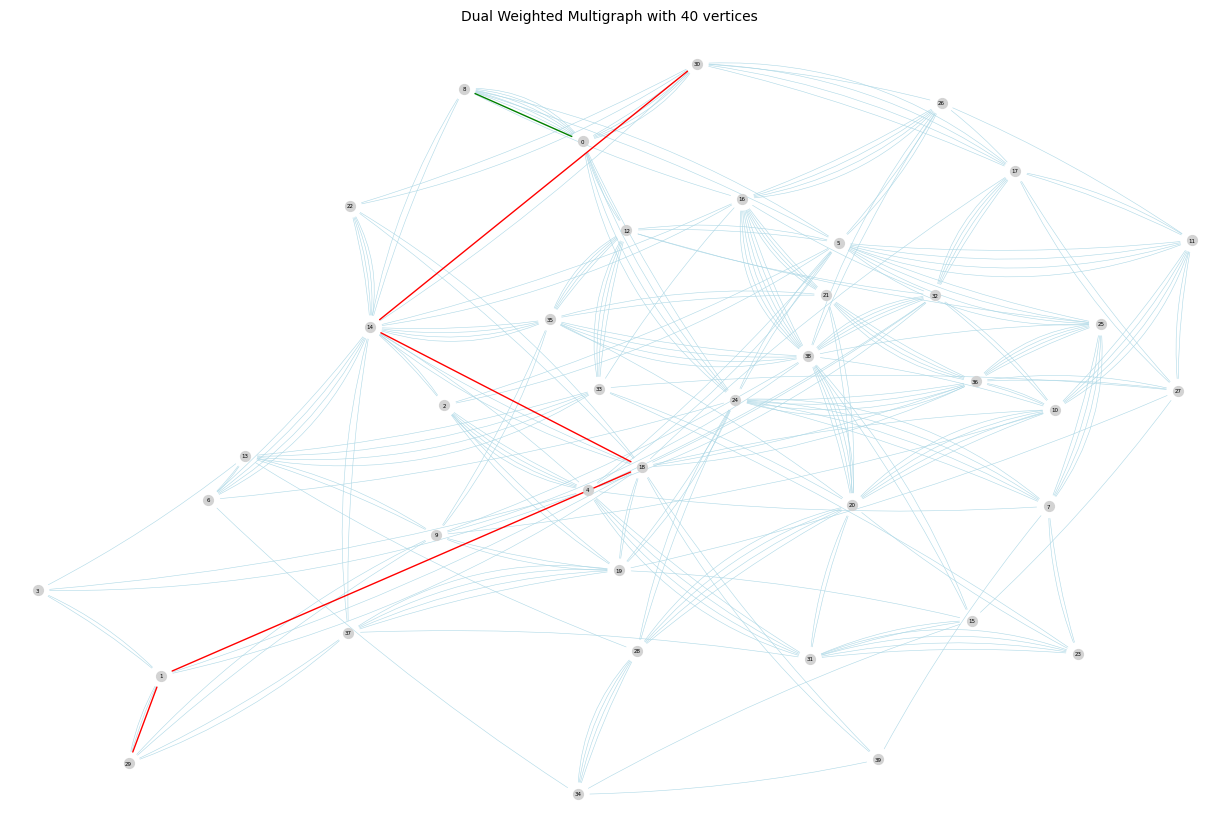

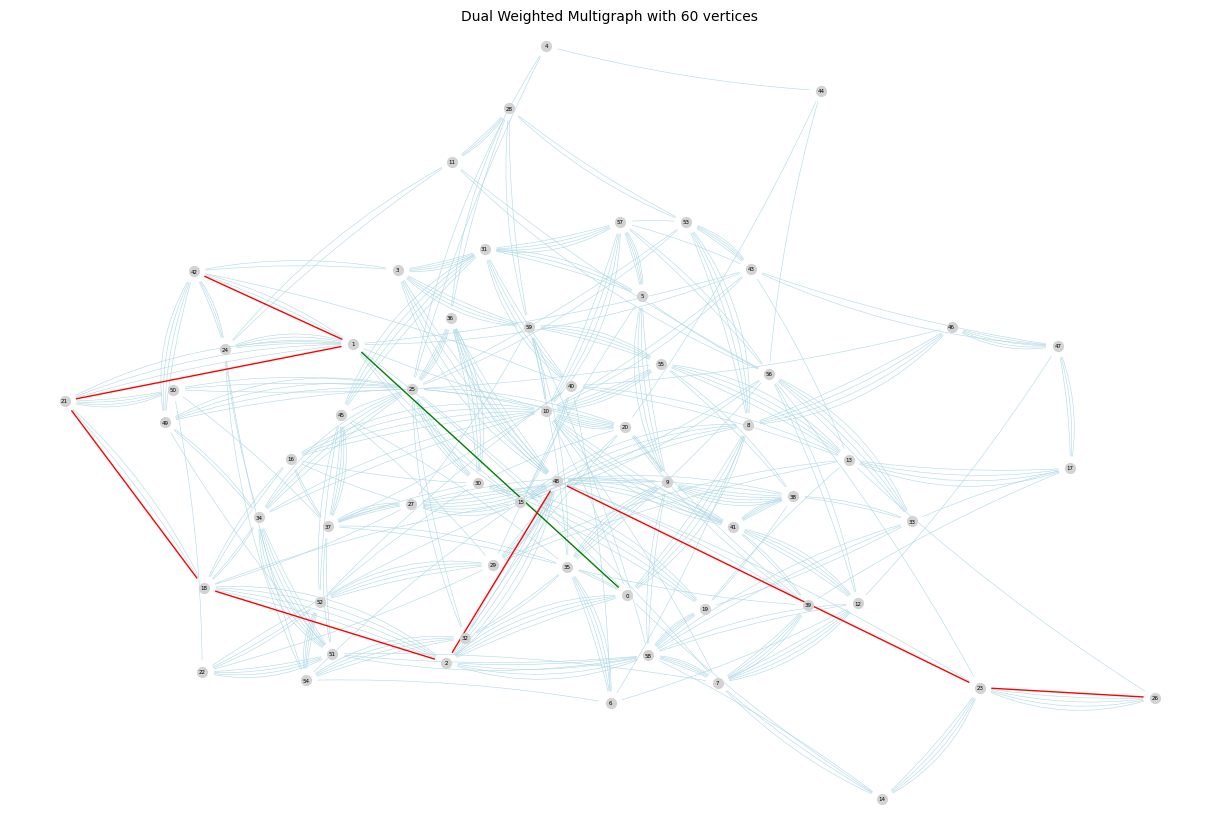

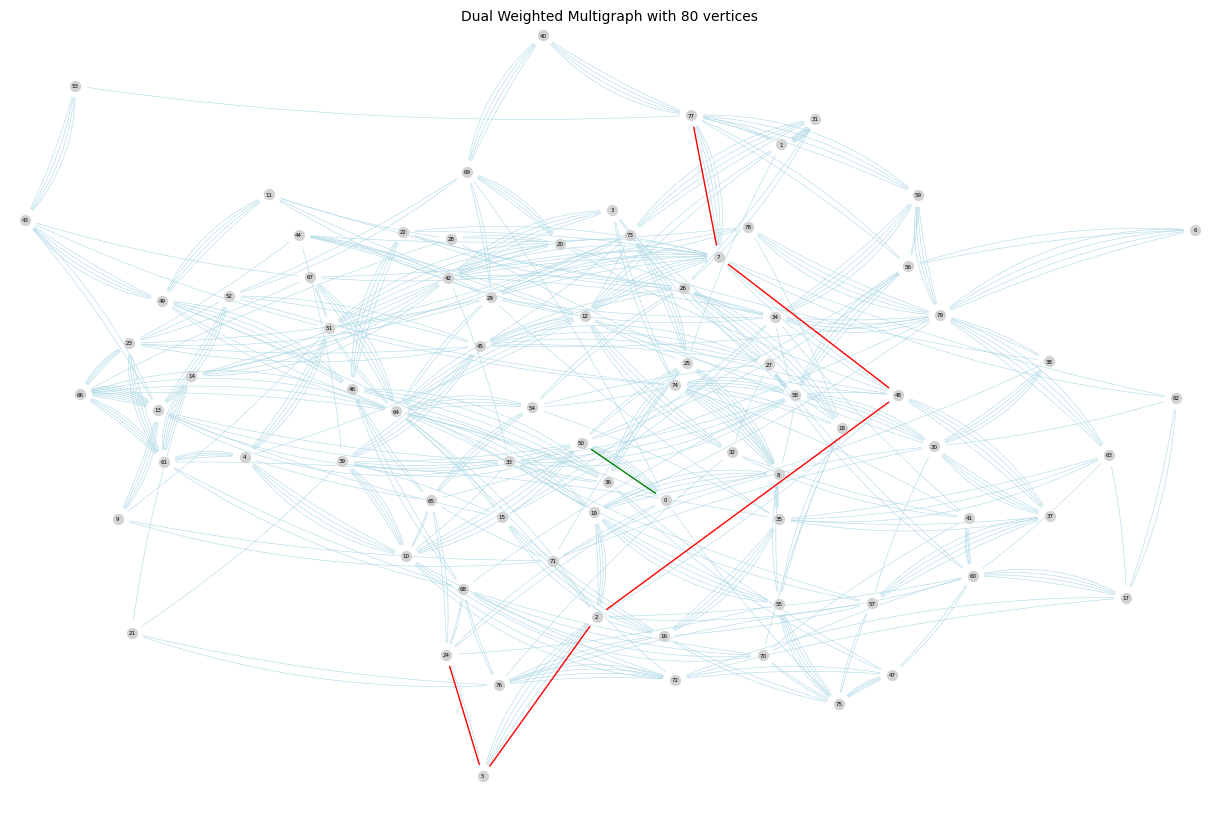

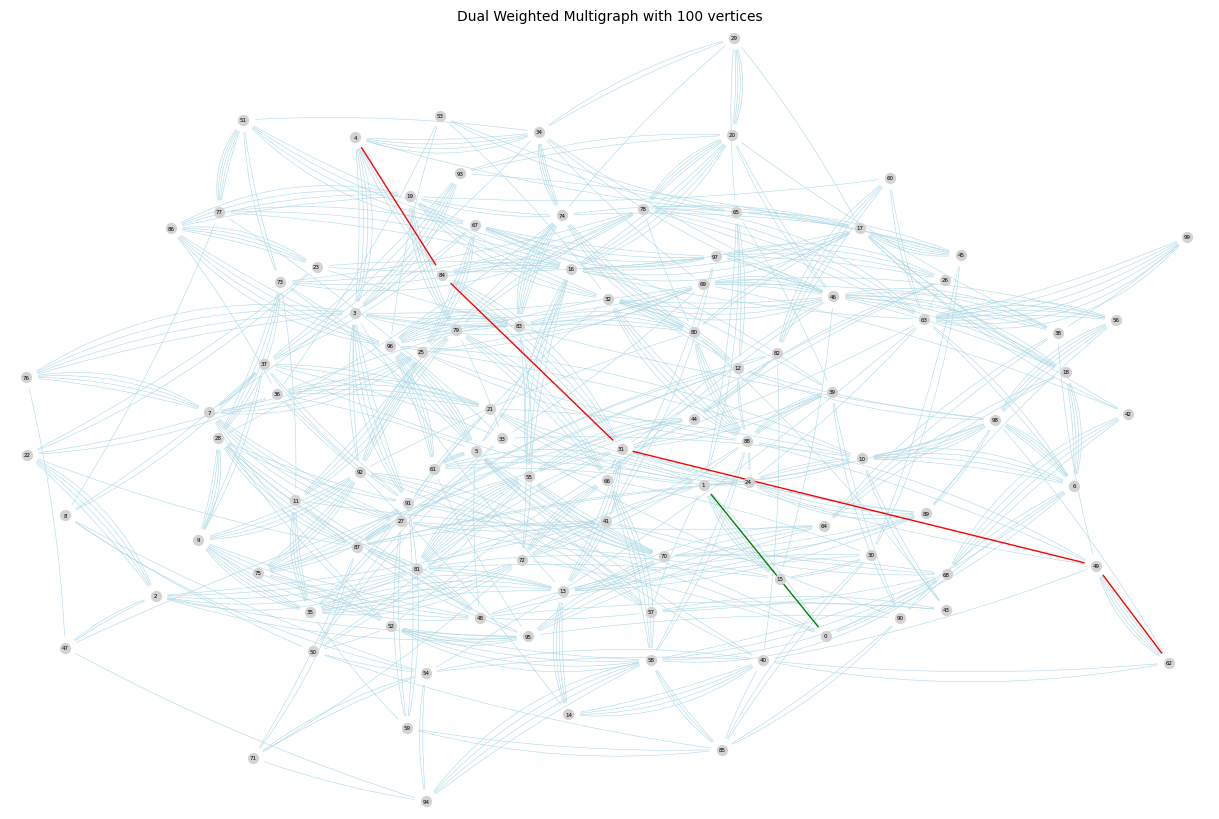

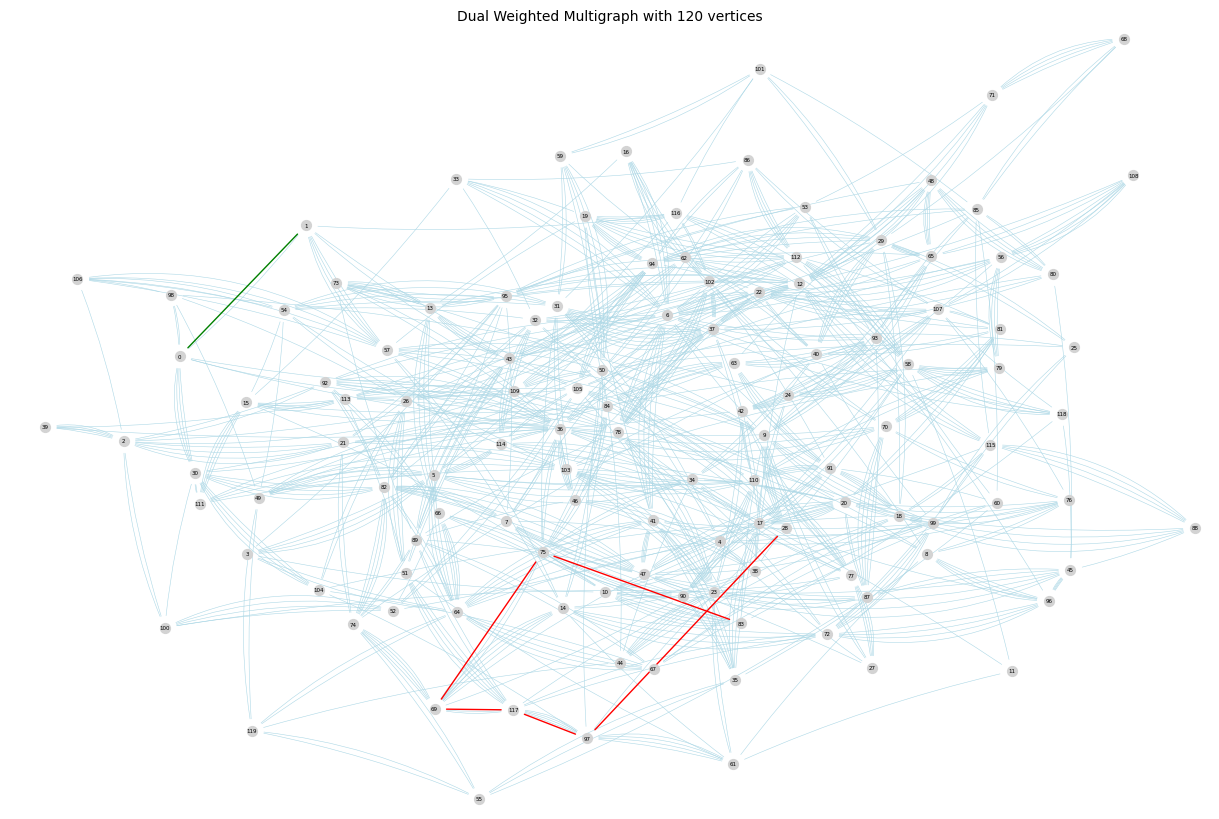

In [21]:
BANDWIDTH_CHOICES = (1, 50, 100)
DELAY_CHOICES = [i * 10 for i in range(1, 11)]

for vertices_num in VERTEXES_NUM_CHOICES:
    edges = generate_dual_weighted_multigraph(
        vertices_num,
        DEGREES_CHOICES,
        MULTIPLE_EDGES_CHOICES,
        WEIGHTS_CHOICES,
        DELAY_CHOICES,
    )

    shortest_paths = calculate_all_dual_weighted_shortest_paths(
        build_dual_weighted_adjacency_list(edges, vertices_num),
        max_delay=200,
    )

    visualize_graph(
        vertices_num,
        edges,
        f"Dual Weighted Multigraph with {vertices_num} vertices",
        select_shortest_path_edges(shortest_paths, 'smallest'),
        select_shortest_path_edges(shortest_paths, 'largest'),
    )

В данной работе была реализована система генерации и анализа неориентированных мультиграфов с различными характеристиками. Графы включали вершины в диапазоне от 40 до 120, степень вершин варьировалась от 2 до 4. Дополнительно в граф добавлялись кратные рёбра. В первом пункте, каждому ребру назначался случайный вес, во втором каждому ребру присваивались два типа весов — пропускная способность  и задержка, что позволяет моделировать реальные сетевые характеристики.

Были сформированы матрицы инцидентности для анализа структуры графа. Для каждого графа реализована визуализация с помощью библиотеки `networkx`, в том числе отображение кратных рёбер с использованием дуг (`arc3`) и выделением кратчайших путей (зелёным цветом) и самых длинных из кратчайших (красным).

Для поиска кратчайших путей между всеми парами вершин использовался алгоритм Дейкстры. Он оптимален по одному критерию (например, минимальной стоимости или длине пути) и имеет вычислительную сложность `O((V + E) log V)` при использовании приоритетной очереди на куче. Его использование оправдано для единичной метрики, когда критична минимизация одного параметра.

Для задач с двумя метриками (например, минимизация стоимости при ограничении на задержку) был реализован и рассмотрен алгоритм DCLC (Delay-Constrained Least-Cost). Он позволяет находить маршруты с минимальной стоимостью, удовлетворяющие заданному ограничению по задержке. Этот алгоритм особенно полезен в системах с требованиями к качеству обслуживания — например, при передаче голоса или видео, где задержка критична. В отличие от Дейкстры, DCLC требует отслеживания не только стоимости, но и накопленной задержки на каждом этапе маршрута. Это делает его потенциально более ресурсоёмким: сложность может быть выше, в зависимости от метода (от `O(E log V)` в приближённой версии до экспоненциальной в переборе всех путей).

Итогом работы стал инструмент анализа мультиграфов с возможностью визуализации, расчёта маршрутов и оценки эффективности алгоритмов. Визуальное выделение путей позволяет проводить наглядный анализ топологии и поведения маршрутизаторов. Алгоритмы Дейкстры и DCLC демонстрируют свои сильные стороны в зависимости от контекста: первый — для простых оптимизаций, второй — для многокритериальных задач с ограничениями.
